In [1]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

True

In [2]:
model = ChatOpenAI()

In [27]:
# state
class State(MessagesState):
    summary: str

In [36]:
# nodes
def call_model(state: State):
    # Call the model with the current message and summary
    messages = []
    if state["summary"]:
        messages.append(SystemMessage(f"Here is the summary of our conversation so far: {state['summary']}"))
         
    messages.extend(state["messages"])
    print(messages)
    
    response = model.invoke(messages)
    
    return {
        "messages":[response],
    }

def summarize(state: State):
    # Summarize the conversation so far
    existing_summary = state["summary"]
    
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."
        
    messages_for_summary = state["messages"] + [HumanMessage(content=prompt)]
   
    response = model.invoke(messages_for_summary)
    
    messages_to_delete = state["messages"][:-2]  # Keep the last 2 messages for context - summary and the message last message
    
    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=msg.id) for msg in messages_to_delete]
    }

In [37]:
def should_summarize(state: State):
    return len(state["messages"]) > 6

In [39]:
builder = StateGraph(State)

builder.add_node("chat", call_model)
builder.add_node("summarize", summarize)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [40]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

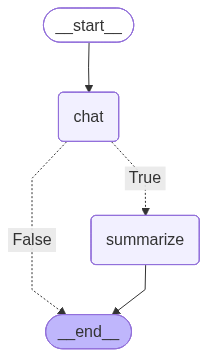

In [16]:

graph


In [41]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [25]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [42]:
run_turn('Quantum Physics')
show_state()


[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='15dec4aa-8aed-4b8a-9c84-b2eeb44830b4')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics is a branch of physics that describes the behavior of particles 


In [43]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='15dec4aa-8aed-4b8a-9c84-b2eeb44830b4'), AIMessage(content='Quantum physics is a branch of physics that describes the behavior of particles on a very small scale, such as atoms and subatomic particles. It is based on the principles of quantum theory, which states that particles can exist in multiple states at the same time and can also exhibit wave-like behavior.\n\nOne of the key principles of quantum physics is the concept of superposition, which states that particles can exist in multiple states simultaneously until they are observed or measured, at which point they collapse into a single state. This principle has led to the development of technologies such as quantum computers, which have the potential to revolutionize computing by using quantum bits, or qubits, that can exist in multiple states at once.\n\nAnother important aspect of quantum physics is the uncertainty principle, which states th


--- STATE ---
summary: 
num_messages: 4
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics is a branch of physics that describes the behavior of particles 
- HumanMessage : How is Albert Einstien related?
- AIMessage : Albert Einstein is closely related to the development of quantum physics, despit


In [44]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='15dec4aa-8aed-4b8a-9c84-b2eeb44830b4'), AIMessage(content='Quantum physics is a branch of physics that describes the behavior of particles on a very small scale, such as atoms and subatomic particles. It is based on the principles of quantum theory, which states that particles can exist in multiple states at the same time and can also exhibit wave-like behavior.\n\nOne of the key principles of quantum physics is the concept of superposition, which states that particles can exist in multiple states simultaneously until they are observed or measured, at which point they collapse into a single state. This principle has led to the development of technologies such as quantum computers, which have the potential to revolutionize computing by using quantum bits, or qubits, that can exist in multiple states at once.\n\nAnother important aspect of quantum physics is the uncertainty principle, which states th

In [45]:
run_turn('Explain special theory of relativity')
show_state()


[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='15dec4aa-8aed-4b8a-9c84-b2eeb44830b4'), AIMessage(content='Quantum physics is a branch of physics that describes the behavior of particles on a very small scale, such as atoms and subatomic particles. It is based on the principles of quantum theory, which states that particles can exist in multiple states at the same time and can also exhibit wave-like behavior.\n\nOne of the key principles of quantum physics is the concept of superposition, which states that particles can exist in multiple states simultaneously until they are observed or measured, at which point they collapse into a single state. This principle has led to the development of technologies such as quantum computers, which have the potential to revolutionize computing by using quantum bits, or qubits, that can exist in multiple states at once.\n\nAnother important aspect of quantum physics is the uncertainty principle, which states th